# Supp Fig 4 — representative spatial vs other tools

Reproduces **SuppFig4** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### SFig 4 spatial — imports & paths
**🟢 light (reads caches)** · source: `fig2c_spatial.ipynb cell 1`

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.patches import Patch
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.dpi': 130,
})

# === Paths (fig2b と一致) ===
BENCH_DIR = BENCHMARK_DB
PRIMARY_TEST = BENCH_DIR / 'adata_hvg_test.h5ad'
FIG2B_DIR = (COMP / 'fig2b')
SCORE_DIR = FIG2B_DIR / 'scores'
VAL_DIR   = FIG2B_DIR / 'val'
OUT_DIR   = (COMP / 'fig2c')
OUT_DIR.mkdir(parents=True, exist_ok=True)

POS, NEG = 'Tumor', 'Normal'
TUMOR_COLOR  = '#F4B183'
NORMAL_COLOR = '#9DC3E6'
SEED = 42

### SFig 4 spatial — load primary scores (parquet)
**🟢 light (reads caches)** · source: `fig2c_spatial.ipynb cell 3`

In [ ]:
# fig2b の primary score を 4 手法分読む (3 baselines は default を使う)
def load_primary_scores():
    methods = {
        'SPATNIC':           ('default',),
        'CancerFinder':      ('default',),
        'scMalignantFinder': ('default',),
        'ikarus':            ('default',),
    }
    out = {}
    for m, variants in methods.items():
        for v in variants:
            p = SCORE_DIR / f'primary_{m}_{v}.parquet'
            if p.exists():
                out[m] = (v, pd.read_parquet(p))
                break
    return out

scores = load_primary_scores()
print('Loaded:', {m: (v, len(df)) for m, (v, df) in scores.items()})
if 'SPATNIC' not in scores:
    raise RuntimeError('SPATNIC primary score が無い。fig2b の score 生成を先に実行してください。')

### SFig 4 spatial — pick_representative_sample
**🟢 light (reads caches)** · source: `fig2c_spatial.ipynb cell 4`

In [ ]:
def pick_representative_sample(scores: dict, threshold: float = 0.5) -> str:
    base = scores['SPATNIC'][1].copy()
    base['spatnic_correct'] = ((base['y_pred'] == base['y_true']))
    others = [m for m in scores if m != 'SPATNIC']
    # 他手法を結合
    merged = base[['cell_id', 'sample', 'y_true', 'spatnic_correct']].copy()
    for m in others:
        sub = scores[m][1][['cell_id', 'y_pred']].rename(columns={'y_pred': f'pred_{m}'})
        merged = merged.merge(sub, on='cell_id', how='inner')
        merged[f'wrong_{m}'] = (merged[f'pred_{m}'] != merged['y_true']).astype(int)
    wrong_cols = [c for c in merged.columns if c.startswith('wrong_')]
    merged['n_others_wrong'] = merged[wrong_cols].sum(axis=1)
    # rescue: SPATNIC 正答 & 他手法少なくとも 2 つ誤答
    merged['rescued'] = merged['spatnic_correct'] & (merged['n_others_wrong'] >= 2)

    # サンプル絞り込み
    summary = merged.groupby('sample').agg(
        n_cells=('cell_id', 'count'),
        frac_tumor=('y_true', lambda s: (s == POS).mean()),
        n_rescued=('rescued', 'sum'),
    )
    summary['frac_rescued'] = summary['n_rescued'] / summary['n_cells']
    elig = summary[(summary['n_cells'] >= 1000)
                   & (summary['frac_tumor'] >= 0.3)
                   & (summary['frac_tumor'] <= 0.7)]
    if not len(elig):
        print('[warn] 条件緩める: tumor 比 0.2-0.8')
        elig = summary[(summary['n_cells'] >= 500)
                       & (summary['frac_tumor'] >= 0.2)
                       & (summary['frac_tumor'] <= 0.8)]
    elig = elig.sort_values('n_rescued', ascending=False)
    print(elig.head(10))
    return elig.index[0], merged

SAMPLE_ID, merged_df = pick_representative_sample(scores)
print(f'\nPicked sample: {SAMPLE_ID}')

### SFig 4 spatial — coords from primary_val.h5ad
**🟢 light (reads caches)** · source: `fig2c_spatial.ipynb cell 6`

In [ ]:
val_h5ad = VAL_DIR / 'primary_val.h5ad'
if not val_h5ad.exists():
    val_h5ad = PRIMARY_TEST
a = ad.read_h5ad(val_h5ad)
obs = a.obs.copy()
obs['cell_id'] = obs.index.astype(str) if 'cell_id' not in obs.columns else obs['cell_id'].astype(str)
# Xenium µm 座標 (DAPI 系) — VALIS warped H&E と同じ系
xy_all = obs[['imagecol', 'imagerow']].to_numpy(dtype=float)
coords = pd.DataFrame({
    'cell_id': obs['cell_id'].values,
    'sample':  obs.get('Sample', obs.get('sample')).astype(str).values,
    'x':       xy_all[:, 0],
    'y':       xy_all[:, 1],
})
coords = coords[coords['sample'] == SAMPLE_ID].copy()
print(f'sample {SAMPLE_ID}: {len(coords)} cells, '
      f'x µm=[{coords["x"].min():.0f}, {coords["x"].max():.0f}], '
      f'y µm=[{coords["y"].min():.0f}, {coords["y"].max():.0f}]')

### Supp Fig 4 — 6-way spatial comparison
**🟢 light (reads caches)** · source: `fig2c_spatial.ipynb cell 8`

In [ ]:
import json
import math
import tifffile

# VALIS で位置合わせ済みの H&E (DAPI 系) を使う
HE_TRANSFORMS_JSON = (COMP / 'groundtruth_overview' / 'he_transforms.json')
# SAMPLE_ID (e.g. 'Pt-1_Resection') → he_transforms.json の key (e.g. 'pt1_resection')
SAMPLE_TO_VALIS_KEY = {
    'Pt-1_Resection': 'pt1_resection',
}

N_COLS = 3  # 2 行 × 3 列レイアウト


def load_warped_he(sample_id: str):
    """warped_HE (DAPI µm 系) と dapi_px_um を返す。なければ (None, None, None)。"""
    key = SAMPLE_TO_VALIS_KEY.get(sample_id)
    if key is None or not HE_TRANSFORMS_JSON.exists():
        return None, None, None
    cache = json.loads(HE_TRANSFORMS_JSON.read_text())
    if key not in cache:
        return None, None, None
    ce = cache[key]
    p = Path(ce['warped_he_path'])
    if not p.exists():
        return None, None, None
    with tifffile.TiffFile(str(p)) as tf:
        img = tf.series[0].asarray()
    if img.ndim == 3 and img.shape[0] in (3, 4) and img.shape[-1] not in (3, 4):
        img = np.transpose(img, (1, 2, 0))
    if img.shape[-1] == 4:
        img = img[..., :3]
    return img, float(ce['dapi_px_um']), p


def normalize_he_for_display(img, *, white_percentile=99.5, black_thresh=8):
    """背景を白に持っていく (NDPI viewer 相当)。VALIS warp 境界の near-black を白に置換。"""
    out = img.astype(np.float32)
    for c in range(3):
        ref = np.percentile(out[..., c], white_percentile)
        if ref > 0:
            out[..., c] = out[..., c] * (255.0 / ref)
    out = np.clip(out, 0, 255).astype(np.uint8)
    mask = (img.sum(axis=2) <= black_thresh)
    if mask.any():
        out[mask] = [255, 255, 255]
    return out


def _spatial_panel(ax, xy, color_arr, *, title, palette, he_img=None, he_px_um=None,
                   point_size=5, alpha=0.95, he_alpha=0.6):
    # H&E only パネル: color_arr=None なら背景だけを濃く描く (overlay 無し)
    he_only = color_arr is None
    if he_img is not None:
        Hi, Wi = he_img.shape[:2]
        ax.imshow(he_img, extent=(0, Wi * he_px_um, Hi * he_px_um, 0),
                   alpha=1.0 if he_only else he_alpha,
                   interpolation='bilinear', zorder=0)
    if not he_only:
        for v, c in palette.items():
            m = (color_arr == v)
            if not m.any():
                continue
            ax.scatter(xy[m, 0], xy[m, 1], s=point_size, c=c,
                        alpha=alpha, linewidths=0, rasterized=True, zorder=2)
    ax.set_aspect('equal')
    if he_img is None:
        ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.5); s.set_color('0.7')
    ax.set_title(title, fontsize=11)


def plot_fig2c():
    sub_coords = coords.set_index('cell_id')
    sub = merged_df[merged_df['sample'] == SAMPLE_ID].copy()
    sub = sub.merge(sub_coords[['x', 'y']], left_on='cell_id', right_index=True, how='inner')
    xy  = sub[['x', 'y']].to_numpy()

    he_img, he_px_um, he_path = load_warped_he(SAMPLE_ID)
    if he_img is not None:
        he_img = normalize_he_for_display(he_img)
        print(f'[H&E] VALIS warped: {he_path} ({he_img.shape}, {he_px_um} µm/px)')
    else:
        print(f'[H&E] no VALIS-aligned H&E for {SAMPLE_ID} — plain background')

    panels = [
        ('H&E', None),
        ('Ground truth', sub['y_true'].values),
        ('SPATNIC',       np.where(sub['spatnic_correct'], sub['y_true'].values,
                                    np.where(sub['y_true'].values == POS, NEG, POS))),
    ]
    available = [c.replace('pred_', '') for c in sub.columns if c.startswith('pred_')]
    ordered = [m for m in ['scMalignantFinder', 'CancerFinder', 'ikarus'] if m in available]
    ordered += [m for m in available if m not in ordered]
    for m in ordered:
        panels.append((m, sub[f'pred_{m}'].astype(str).values))
    palette = {POS: TUMOR_COLOR, NEG: NORMAL_COLOR}

    n = len(panels)
    n_cols = N_COLS
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 3.4 * n_rows), dpi=140)
    axes_flat = np.atleast_1d(axes).ravel()

    # 全パネル共通の view (細胞 bounding box + 100 µm padding)
    pad = 100.0
    x0, x1 = xy[:, 0].min() - pad, xy[:, 0].max() + pad
    y0, y1 = xy[:, 1].min() - pad, xy[:, 1].max() + pad

    for ax, (title, color_arr) in zip(axes_flat, panels):
        _spatial_panel(ax, xy, color_arr, title=title, palette=palette,
                        he_img=he_img, he_px_um=he_px_um)
        ax.set_xlim(x0, x1)
        ax.set_ylim(y1, y0)  # image-y (y down)

    # 余った subplot (panels 数 < n_rows*n_cols) は非表示
    for ax in axes_flat[n:]:
        ax.set_visible(False)

    handles = [Patch(facecolor=TUMOR_COLOR, label='Tumor'),
                Patch(facecolor=NORMAL_COLOR, label='Normal')]
    fig.legend(handles=handles, loc='upper center',
                bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)
    fig.suptitle(SAMPLE_ID, y=1.06, fontsize=11)
    fig.tight_layout()
    for ext in ('png', 'pdf'):
        p = OUT_DIR / f'fig2c.{ext}'
        fig.savefig(p)
        print(f'[saved] {p}')
    plt.show()

plot_fig2c()

### SFig 4 spatial — galaxy 2-1 epithelial load
**🟡 moderate** · source: `fig2c_spatial.ipynb cell 10`

In [ ]:
# --- Sample 2-1 epithelial cells: 座標 + SPATNIC 予測の読み込み ---
GALAXY_H5AD     = DATA_ROOT / 'GxD_xenium_concat_filtered_sample_split.h5ad'
SPATNIC_2_1_CSV = BACKUP_ROOT / '2-1.csv'

g = ad.read_h5ad(GALAXY_H5AD, backed='r')
mask_2_1 = (
    (g.obs['Sample'].astype(str) == '2-1')
    & (g.obs['Cell_type'].astype(str) == 'Epithelial')
)
obs_2_1 = g.obs[mask_2_1].copy()
obs_2_1['cell_id'] = obs_2_1.index.astype(str)

# SPATNIC predictions (group: Malignant → Tumor, Epithelial → Normal)
GROUP_TO_LABEL = {'Malignant': POS, 'Epithelial': NEG}
pred_2_1 = pd.read_csv(SPATNIC_2_1_CSV)
pred_2_1['SPATNIC'] = pred_2_1['group'].map(GROUP_TO_LABEL)

df_2_1 = pd.DataFrame({
    'cell_id': obs_2_1['cell_id'].values,
    'x':       obs_2_1['imagecol'].astype(float).values,  # Xenium µm
    'y':       obs_2_1['imagerow'].astype(float).values,
}).merge(pred_2_1[['cell_id', 'SPATNIC']], on='cell_id', how='inner')

print(f'Sample 2-1 epithelial: {len(df_2_1)} / {mask_2_1.sum()} cells '
       f'(matched to SPATNIC predictions)')
print('SPATNIC pred:', df_2_1['SPATNIC'].value_counts().to_dict())
print(f'µm range: x=[{df_2_1["x"].min():.0f}, {df_2_1["x"].max():.0f}], '
       f'y=[{df_2_1["y"].min():.0f}, {df_2_1["y"].max():.0f}]')

### Supp Fig 4 — 6-way spatial comparison (galaxy 2-1 panels)
**🟡 moderate** · source: `fig2c_spatial.ipynb cell 11`

In [ ]:
# --- 汎用 plot 関数 (任意 sample に再利用可) ---
def plot_sample_panels(df, *, sample_id, sample_label,
                        pred_columns=('SPATNIC', 'scMalignantFinder',
                                       'CancerFinder', 'ikarus'),
                        gt_column='y_true',
                        n_cols=3, point_size=3, file_stem=None):
    """H&E + (GT) + あるだけの prediction 列を順番にパネル化。"""
    he_img, he_px_um, he_path = load_warped_he(sample_id)
    if he_img is not None:
        he_img = normalize_he_for_display(he_img)
        print(f'[H&E] VALIS warped: {he_path} ({he_img.shape}, {he_px_um} µm/px)')
    else:
        print(f'[H&E] no VALIS-aligned H&E for {sample_id} — '
               f'plain background. plot_groundtruth_overview.ipynb の '
               f'he-valis-run step で {sample_id} を追加してください。')

    panels = [('H&E', None)]
    if gt_column in df.columns and df[gt_column].notna().any():
        panels.append(('Ground truth', df[gt_column].astype(str).values))
    for col in pred_columns:
        if col in df.columns and df[col].notna().any():
            panels.append((col, df[col].astype(str).values))

    palette = {POS: TUMOR_COLOR, NEG: NORMAL_COLOR}
    xy = df[['x', 'y']].to_numpy()

    n = len(panels)
    n_cols_eff = min(n_cols, n)
    n_rows = math.ceil(n / n_cols_eff)
    fig, axes = plt.subplots(n_rows, n_cols_eff,
                              figsize=(2.8 * n_cols_eff, 3.4 * n_rows), dpi=140)
    axes_flat = np.atleast_1d(axes).ravel()

    pad = 100.0
    x0, x1 = xy[:, 0].min() - pad, xy[:, 0].max() + pad
    y0, y1 = xy[:, 1].min() - pad, xy[:, 1].max() + pad

    for ax, (title, color_arr) in zip(axes_flat, panels):
        _spatial_panel(ax, xy, color_arr, title=title, palette=palette,
                        he_img=he_img, he_px_um=he_px_um,
                        point_size=point_size)
        ax.set_xlim(x0, x1)
        ax.set_ylim(y1, y0)
    for ax in axes_flat[n:]:
        ax.set_visible(False)

    handles = [Patch(facecolor=TUMOR_COLOR, label='Tumor'),
                Patch(facecolor=NORMAL_COLOR, label='Normal')]
    fig.legend(handles=handles, loc='upper center',
                bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)
    fig.suptitle(sample_label, y=1.06, fontsize=11)
    fig.tight_layout()
    stem = file_stem or f'fig2c_{sample_id}'
    for ext in ('png', 'pdf'):
        p = OUT_DIR / f'{stem}.{ext}'
        fig.savefig(p)
        print(f'[saved] {p}')
    plt.show()


# --- 3 default baseline 予測を merge ---
GALAXY_PARQUET_TEMPLATE = SCORE_DIR / 'galaxy2-1_{method}_default.parquet'
_BASELINE_METHODS = ('scMalignantFinder', 'CancerFinder', 'ikarus')

# cell の再実行で列が二重 merge されるのを防ぐため、既存の baseline 列を drop
df_2_1 = df_2_1.drop(columns=[c for c in _BASELINE_METHODS if c in df_2_1.columns])

for m in _BASELINE_METHODS:
    p = Path(str(GALAXY_PARQUET_TEMPLATE).format(method=m))
    if not p.exists():
        print(f'[skip] {m}: {p} 未生成 (notebook 末尾の prediction セルを実行してください)')
        continue
    sub = pd.read_parquet(p)[['cell_id', 'y_pred']].rename(columns={'y_pred': m})
    df_2_1 = df_2_1.merge(sub, on='cell_id', how='left')
    print(f'merged {m}: {df_2_1[m].value_counts().to_dict()}')


# --- Plot Sample 2-1: H&E (VALIS-aligned) + 4 method overlays ---
SAMPLE_TO_VALIS_KEY['2-1'] = '2-1'  # he_transforms.json のキー (VALIS run 済み)

plot_sample_panels(
    df_2_1,
    sample_id='2-1',
    sample_label='GALAXY 2-1 — Epithelial',
    n_cols=3,        # 5 panel → 2 行 × 3 列
    point_size=0.1,  # 細胞数が多い (114k) ので小さめ
)

## Published result (reference)
Embedded reference output; the code above regenerates it.

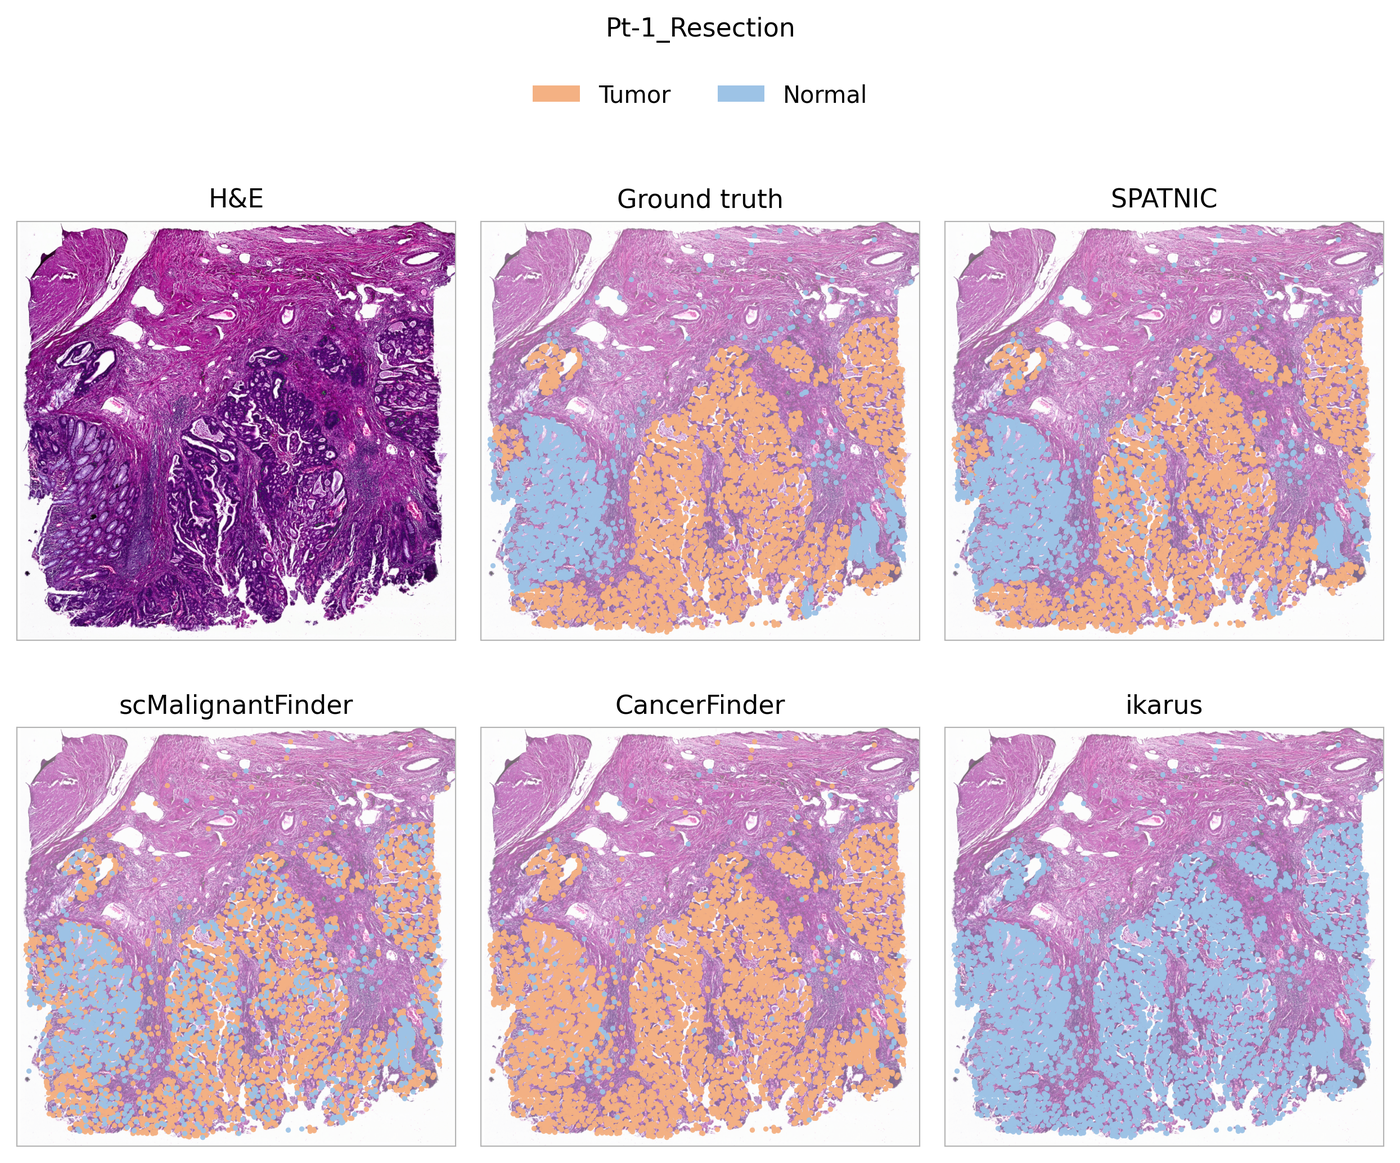

In [ ]:
# 6-way spatial comparison
Image(str(COMP / "fig2c/fig2c.png"))